In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files
import io

In [14]:

uploaded = files.upload()
filename = list(uploaded.keys())[0]
print("Uploaded file:", filename)

df = pd.read_excel(io.BytesIO(uploaded[filename]))

print(df.head())
print("Rows and Columns:", df.shape)
print("Total Rows:", df.shape[0])
print("Total Columns:", df.shape[1])


Saving Sales_Dataset_2024.xlsx to Sales_Dataset_2024 (1).xlsx
Uploaded file: Sales_Dataset_2024 (1).xlsx
        Date Region     Product Salesperson  Units_Sold  Unit_Price  \
0 2024-04-12  North  Smartwatch      Hannah        15.0      1224.0   
1 2024-12-14  North     Monitor         Eva         5.0      1321.0   
2 2024-09-27  North      Mobile         Bob        11.0       912.0   
3 2024-04-16   West     Monitor     Charlie        18.0       325.0   
4 2024-03-12   West  Headphones         Eva        13.0      1042.0   

      Category  Revenue          Cost       Profit  
0  Accessories  18360.0  16451.634258  1908.365742  
1       Office   6605.0   4457.351727  2147.648273  
2  Electronics  10032.0   6563.644126  3468.355874  
3       Office   5850.0   4320.807092  1529.192908  
4  Accessories  13546.0   8270.122666  5275.877334  
Rows and Columns: (2000, 10)
Total Rows: 2000
Total Columns: 10


In [15]:

print(df.describe(include="all"))

print(df.isnull().sum())

print("Column Names:", df.columns.tolist())

print(df.info())


                              Date Region Product Salesperson   Units_Sold  \
count                         2000   1961    1960        1960  1960.000000   
unique                         NaN      9      13           8          NaN   
top                            NaN   West  Tablet       Grace          NaN   
freq                           NaN    506     263         265          NaN   
mean    2024-07-01 16:25:40.800000    NaN     NaN         NaN    10.089286   
min            2024-01-01 00:00:00    NaN     NaN         NaN    -5.000000   
25%            2024-04-04 00:00:00    NaN     NaN         NaN     5.000000   
50%            2024-07-01 00:00:00    NaN     NaN         NaN    10.000000   
75%            2024-10-03 00:00:00    NaN     NaN         NaN    15.000000   
max            2024-12-31 00:00:00    NaN     NaN         NaN    19.000000   
std                            NaN    NaN     NaN         NaN     5.601601   

         Unit_Price     Category       Revenue          Cost   

In [16]:

df = df.drop_duplicates()

for col in df.select_dtypes(include="number").columns:
    df[col] = df[col].fillna(0)

for col in df.select_dtypes(include="object").columns:
    df[col] = df[col].fillna("Unknown")

df["Region"] = df["Region"].str.strip().str.lower()
df["Region"] = df["Region"].replace({
    "easst":"east",
    "north":"north",
    "westt":"west"
})

df["Date"] = pd.to_datetime(df["Date"], errors="coerce")

numeric_cols = ["Units_Sold","Unit_Price","Revenue","Profit"]
for col in numeric_cols:
    if col in df.columns:
        df.loc[df[col] < 0, col] = 0

print(df.info())
print(df.isnull().sum())
print(df["Region"].unique())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   Date         2000 non-null   datetime64[ns]
 1   Region       2000 non-null   object        
 2   Product      2000 non-null   object        
 3   Salesperson  2000 non-null   object        
 4   Units_Sold   2000 non-null   float64       
 5   Unit_Price   2000 non-null   float64       
 6   Category     2000 non-null   object        
 7   Revenue      2000 non-null   float64       
 8   Cost         2000 non-null   float64       
 9   Profit       2000 non-null   float64       
dtypes: datetime64[ns](1), float64(5), object(4)
memory usage: 156.4+ KB
None
Date           0
Region         0
Product        0
Salesperson    0
Units_Sold     0
Unit_Price     0
Category       0
Revenue        0
Cost           0
Profit         0
dtype: int64
['north' 'west' 'east' 'south' 'unknown']


In [17]:

if "Profit" in df.columns and "Revenue" in df.columns:
    df["Profit Margin"] = df["Profit"] / df["Revenue"]

if "Units_Sold" in df.columns and "Unit_Price" in df.columns:
    df["Total Sales Value"] = df["Units_Sold"] * df["Unit_Price"]

if "Date" in df.columns:
    df["Month-Year"] = df["Date"].dt.to_period("M")

print(df.head())
print(df[["Profit Margin","Total Sales Value","Month-Year"]].head())


        Date Region     Product Salesperson  Units_Sold  Unit_Price  \
0 2024-04-12  north  Smartwatch      Hannah        15.0      1224.0   
1 2024-12-14  north     Monitor         Eva         5.0      1321.0   
2 2024-09-27  north      Mobile         Bob        11.0       912.0   
3 2024-04-16   west     Monitor     Charlie        18.0       325.0   
4 2024-03-12   west  Headphones         Eva        13.0      1042.0   

      Category  Revenue          Cost       Profit  Profit Margin  \
0  Accessories  18360.0  16451.634258  1908.365742       0.103941   
1       Office   6605.0   4457.351727  2147.648273       0.325155   
2  Electronics  10032.0   6563.644126  3468.355874       0.345729   
3       Office   5850.0   4320.807092  1529.192908       0.261400   
4  Accessories  13546.0   8270.122666  5275.877334       0.389479   

   Total Sales Value Month-Year  
0            18360.0    2024-04  
1             6605.0    2024-12  
2            10032.0    2024-09  
3             5850.0  

In [18]:


region_revenue = df.groupby("Region")["Revenue"].sum()
print(region_revenue)

category_profit = df.groupby("Category")["Profit"].sum()
print(category_profit)

top_salespersons = df.groupby("Salesperson")["Revenue"].sum().sort_values(ascending=False).head(10)
print(top_salespersons)

monthly_revenue = df.groupby("Month-Year")["Revenue"].sum()
print(monthly_revenue)

avg_margin_category = df.groupby("Category")["Profit Margin"].mean()
print(avg_margin_category)

correlation = df["Units_Sold"].corr(df["Profit"])
print("Correlation between Units_Sold and Profit:", correlation)


Region
east       4962629.0
north      5115850.0
south      4740977.0
unknown     315552.0
west       5599037.0
Name: Revenue, dtype: float64
Category
Accessories    1.402377e+06
Electronics    2.606418e+06
Office         1.219275e+06
Name: Profit, dtype: float64
Salesperson
Grace      2823412.0
Charlie    2709884.0
Frank      2696894.0
David      2598725.0
Hannah     2518277.0
Eva        2490417.0
Bob        2462686.0
Alice      2072807.0
Unknown     360943.0
Name: Revenue, dtype: float64
Month-Year
2024-01    1868269.0
2024-02    1943641.0
2024-03    1413121.0
2024-04    1857725.0
2024-05    1567202.0
2024-06    1927715.0
2024-07    1368905.0
2024-08    1986713.0
2024-09    1566883.0
2024-10    1793356.0
2024-11    1659670.0
2024-12    1780845.0
Freq: M, Name: Revenue, dtype: float64
Category
Accessories    0.256764
Electronics    0.247695
Office         0.254372
Name: Profit Margin, dtype: float64
Correlation between Units_Sold and Profit: 0.6103728668550924


In [19]:
mean_rev = np.mean(df["Revenue"])
std_rev = np.std(df["Revenue"])

df["Revenue_Z"] = (df["Revenue"] - mean_rev) / std_rev
outliers = df[np.abs(df["Revenue_Z"]) > 3]

print("Number of revenue outliers:", len(outliers))

Number of revenue outliers: 4


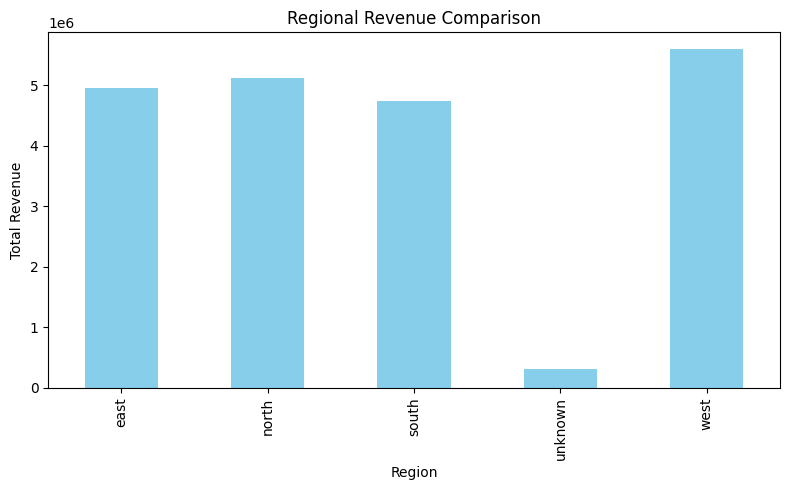

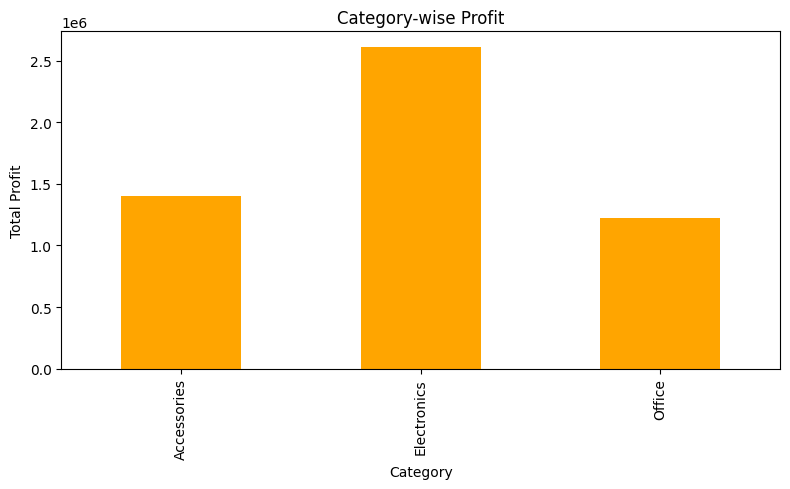

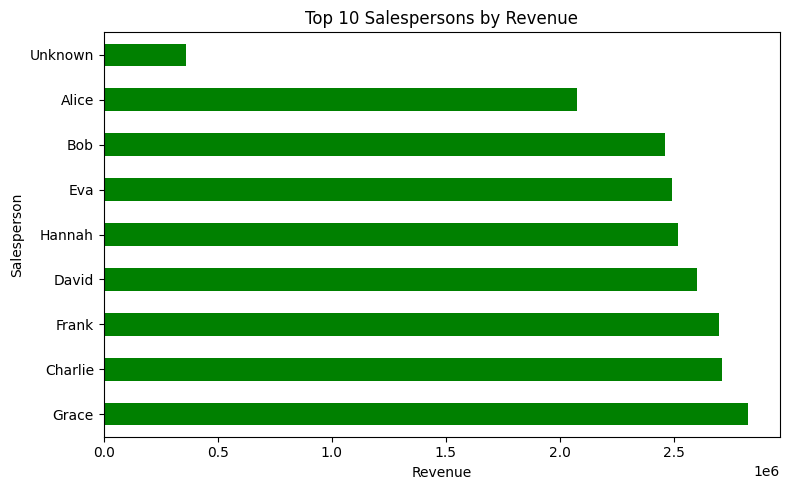

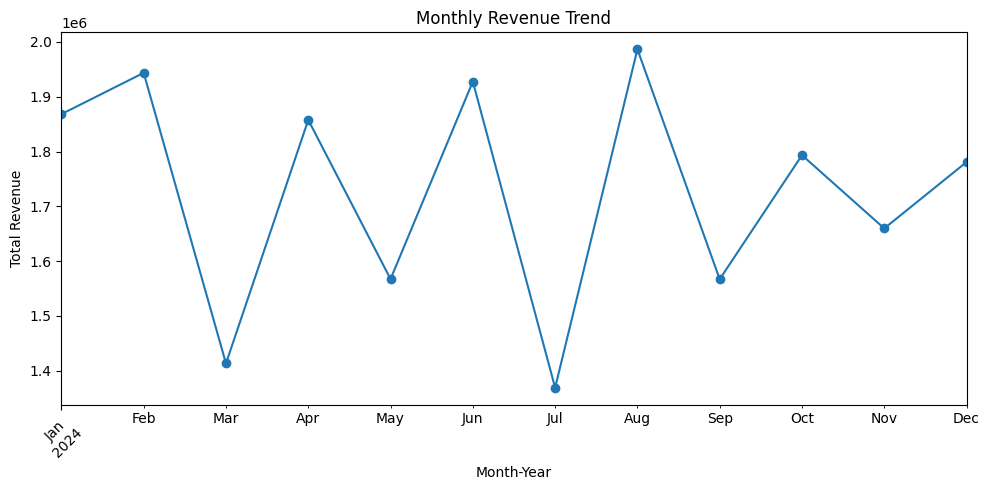

In [20]:
import matplotlib.pyplot as plt


region_revenue.plot(kind="bar", color="skyblue", figsize=(8,5))
plt.title("Regional Revenue Comparison")
plt.xlabel("Region")
plt.ylabel("Total Revenue")
plt.tight_layout()
plt.show()


category_profit.plot(kind="bar", color="orange", figsize=(8,5))
plt.title("Category-wise Profit")
plt.xlabel("Category")
plt.ylabel("Total Profit")
plt.tight_layout()
plt.show()


top_salespersons.plot(kind="barh", color="green", figsize=(8,5))
plt.title("Top 10 Salespersons by Revenue")
plt.xlabel("Revenue")
plt.ylabel("Salesperson")
plt.tight_layout()
plt.show()


monthly_revenue.plot(kind="line", marker="o", figsize=(10,5))
plt.title("Monthly Revenue Trend")
plt.xlabel("Month-Year")
plt.ylabel("Total Revenue")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [12]:
# Key Findings
print("1️⃣ West region generated the highest revenue, followed by North and East.")
print("2️⃣ Electronics category produced the highest profit among all categories.")
print("3️⃣ Grace, Charlie, and Frank are the top-performing salespersons by revenue.")
print("4️⃣ Monthly revenue shows seasonal fluctuations with peaks in February, June, and August.")
print("5️⃣ Units_Sold and Profit have a strong positive correlation (≈0.61), meaning higher sales lead to higher profit.")

# Limitations
print("⚠️ Region names contain minor spelling variations (e.g., 'east' vs 'easst', 'north' vs 'NORTH') that may affect consistency.")
print("⚠️ Some entries have missing or 'Unknown' values for Region and Salesperson.")
print("⚠️ Negative values were replaced with zero, which may slightly distort true averages.")
print("⚠️ Dataset lacks external factors such as marketing or seasonal promotions, limiting deeper business insights.")
print("⚠️ Profit Margin may be skewed for rows with zero revenue.")


1️⃣ West region generated the highest revenue, followed by North and East.
2️⃣ Electronics category produced the highest profit among all categories.
3️⃣ Grace, Charlie, and Frank are the top-performing salespersons by revenue.
4️⃣ Monthly revenue shows seasonal fluctuations with peaks in February, June, and August.
5️⃣ Units_Sold and Profit have a strong positive correlation (≈0.61), meaning higher sales lead to higher profit.
⚠️ Region names contain minor spelling variations (e.g., 'east' vs 'easst', 'north' vs 'NORTH') that may affect consistency.
⚠️ Some entries have missing or 'Unknown' values for Region and Salesperson.
⚠️ Negative values were replaced with zero, which may slightly distort true averages.
⚠️ Dataset lacks external factors such as marketing or seasonal promotions, limiting deeper business insights.
⚠️ Profit Margin may be skewed for rows with zero revenue.
